# Understanding the Bootstrap Plot

A **bootstrap plot** visualises the **sampling distribution of a statistic** (mean, median, standard deviation, etc.) without assuming any parametric distribution. Bootstrap resampling draws B random samples with replacement from the original data, computes the statistic on each sample, and plots the resulting distribution. This gives a non-parametric estimate of the statistic's uncertainty.

**Three-panel bootstrap plot:**
1. **Sampling distribution histogram** — shows the distribution of the bootstrapped statistic
2. **Confidence interval** — percentile interval [2.5%, 97.5%] gives a 95% CI
3. **Stability plot** — the bootstrap estimates in order of draw, checking for convergence

**Why bootstrap?**
- Works even when the statistic has no simple closed-form distribution
- No normality assumption required
- Easily extended to any statistic (correlation, AUC, regression coefficients, etc.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

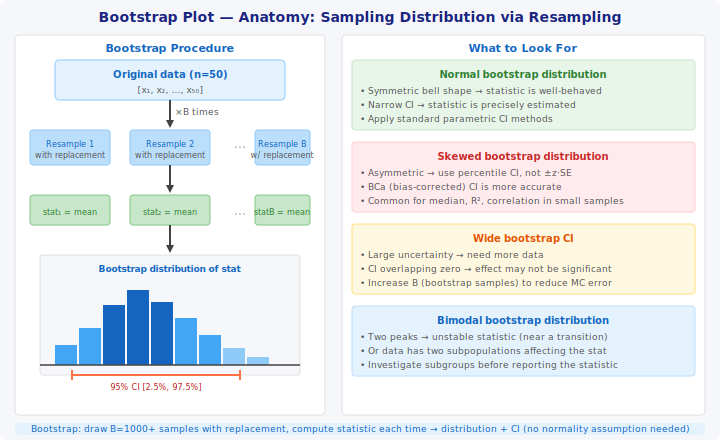

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Bootstrap Plot — Anatomy: Sampling Distribution via Resampling</text>

  <!-- ── LEFT: Bootstrap procedure diagram ── -->
  <rect x="15" y="35" width="310" height="380" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="170" y="52" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">Bootstrap Procedure</text>

  <!-- Original data -->
  <rect x="55" y="60" width="230" height="40" fill="#E3F2FD" stroke="#90CAF9" rx="4"/>
  <text x="170" y="78" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Original data (n=50)</text>
  <text x="170" y="93" text-anchor="middle" font-size="9" fill="#555">[x₁, x₂, ..., x₅₀]</text>

  <!-- Arrow down -->
  <line x1="170" y1="100" x2="170" y2="120" stroke="#424242" stroke-width="2"/>
  <polygon points="166,120 174,120 170,128" fill="#424242"/>
  <text x="175" y="115" font-size="9" fill="#555">×B times</text>

  <!-- Resample boxes -->
  <rect x="30"  y="130" width="80" height="35" fill="#BBDEFB" stroke="#90CAF9" rx="3"/>
  <text x="70" y="147" text-anchor="middle" font-size="8" fill="#1565C0">Resample 1</text>
  <text x="70" y="158" text-anchor="middle" font-size="8" fill="#555">with replacement</text>

  <rect x="130" y="130" width="80" height="35" fill="#BBDEFB" stroke="#90CAF9" rx="3"/>
  <text x="170" y="147" text-anchor="middle" font-size="8" fill="#1565C0">Resample 2</text>
  <text x="170" y="158" text-anchor="middle" font-size="8" fill="#555">with replacement</text>

  <text x="240" y="148" text-anchor="middle" font-size="12" fill="#9E9E9E">...</text>

  <rect x="255" y="130" width="55" height="35" fill="#BBDEFB" stroke="#90CAF9" rx="3"/>
  <text x="282" y="147" text-anchor="middle" font-size="8" fill="#1565C0">Resample B</text>
  <text x="282" y="158" text-anchor="middle" font-size="8" fill="#555">w/ replacement</text>

  <!-- Arrow down -->
  <line x1="170" y1="165" x2="170" y2="185" stroke="#424242" stroke-width="2"/>
  <polygon points="166,185 174,185 170,193" fill="#424242"/>

  <!-- Statistic boxes -->
  <rect x="30"  y="195" width="80" height="30" fill="#C8E6C9" stroke="#81C784" rx="3"/>
  <text x="70" y="215" text-anchor="middle" font-size="8" fill="#2E7D32">stat₁ = mean</text>

  <rect x="130" y="195" width="80" height="30" fill="#C8E6C9" stroke="#81C784" rx="3"/>
  <text x="170" y="215" text-anchor="middle" font-size="8" fill="#2E7D32">stat₂ = mean</text>

  <text x="240" y="215" text-anchor="middle" font-size="12" fill="#9E9E9E">...</text>

  <rect x="255" y="195" width="55" height="30" fill="#C8E6C9" stroke="#81C784" rx="3"/>
  <text x="282" y="215" text-anchor="middle" font-size="8" fill="#2E7D32">statB = mean</text>

  <!-- Arrow -->
  <line x1="170" y1="225" x2="170" y2="245" stroke="#424242" stroke-width="2"/>
  <polygon points="166,245 174,245 170,253" fill="#424242"/>

  <!-- Histogram of bootstrap stats -->
  <rect x="40" y="255" width="260" height="120" fill="#F5F7FA" stroke="#E0E0E0" rx="3"/>
  <text x="170" y="272" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">Bootstrap distribution of stat</text>
  <!-- bars -->
  <rect x="55"  y="345" width="22" height="20" fill="#42A5F5"/>
  <rect x="79"  y="328" width="22" height="37" fill="#42A5F5"/>
  <rect x="103" y="305" width="22" height="60" fill="#1565C0"/>
  <rect x="127" y="290" width="22" height="75" fill="#1565C0"/>
  <rect x="151" y="302" width="22" height="63" fill="#1565C0"/>
  <rect x="175" y="318" width="22" height="47" fill="#42A5F5"/>
  <rect x="199" y="335" width="22" height="30" fill="#42A5F5"/>
  <rect x="223" y="348" width="22" height="17" fill="#90CAF9"/>
  <rect x="247" y="357" width="22" height="8"  fill="#90CAF9"/>
  <line x1="40" y1="365" x2="300" y2="365" stroke="#424242" stroke-width="1.5"/>
  <!-- CI brackets -->
  <line x1="72"  y1="375" x2="240" y2="375" stroke="#FF7043" stroke-width="2"/>
  <line x1="72"  y1="370" x2="72"  y2="380" stroke="#FF7043" stroke-width="2"/>
  <line x1="240" y1="370" x2="240" y2="380" stroke="#FF7043" stroke-width="2"/>
  <text x="156" y="390" text-anchor="middle" font-size="8" fill="#B71C1C">95% CI [2.5%, 97.5%]</text>

  <!-- ── RIGHT: what to look for ── -->
  <rect x="342" y="35" width="363" height="380" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="523" y="52" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">What to Look For</text>

  <rect x="352" y="60" width="343" height="70" fill="#E8F5E9" stroke="#C8E6C9" rx="3"/>
  <text x="523" y="78" text-anchor="middle" font-size="10" font-weight="bold" fill="#2E7D32">Normal bootstrap distribution</text>
  <text x="360" y="94" font-size="9" fill="#555">• Symmetric bell shape → statistic is well-behaved</text>
  <text x="360" y="108" font-size="9" fill="#555">• Narrow CI → statistic is precisely estimated</text>
  <text x="360" y="122" font-size="9" fill="#555">• Apply standard parametric CI methods</text>

  <rect x="352" y="142" width="343" height="70" fill="#FFEBEE" stroke="#FFCDD2" rx="3"/>
  <text x="523" y="160" text-anchor="middle" font-size="10" font-weight="bold" fill="#C62828">Skewed bootstrap distribution</text>
  <text x="360" y="176" font-size="9" fill="#555">• Asymmetric → use percentile CI, not ±z·SE</text>
  <text x="360" y="190" font-size="9" fill="#555">• BCa (bias-corrected) CI is more accurate</text>
  <text x="360" y="204" font-size="9" fill="#555">• Common for median, R², correlation in small samples</text>

  <rect x="352" y="224" width="343" height="70" fill="#FFF8E1" stroke="#FFE082" rx="3"/>
  <text x="523" y="242" text-anchor="middle" font-size="10" font-weight="bold" fill="#E65100">Wide bootstrap CI</text>
  <text x="360" y="258" font-size="9" fill="#555">• Large uncertainty → need more data</text>
  <text x="360" y="272" font-size="9" fill="#555">• CI overlapping zero → effect may not be significant</text>
  <text x="360" y="286" font-size="9" fill="#555">• Increase B (bootstrap samples) to reduce MC error</text>

  <rect x="352" y="306" width="343" height="70" fill="#E3F2FD" stroke="#BBDEFB" rx="3"/>
  <text x="523" y="324" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Bimodal bootstrap distribution</text>
  <text x="360" y="340" font-size="9" fill="#555">• Two peaks → unstable statistic (near a transition)</text>
  <text x="360" y="354" font-size="9" fill="#555">• Or data has two subpopulations affecting the stat</text>
  <text x="360" y="368" font-size="9" fill="#555">• Investigate subgroups before reporting the statistic</text>

  <!-- Takeaway -->
  <rect x="15" y="423" width="690" height="12" fill="#E3F2FD" rx="3"/>
  <text x="360" y="432" text-anchor="middle" font-size="9" fill="#1565C0">
    Bootstrap: draw B=1000+ samples with replacement, compute statistic each time → distribution + CI (no normality assumption needed)
  </text>
</svg>
"""
display(SVG(_svg))

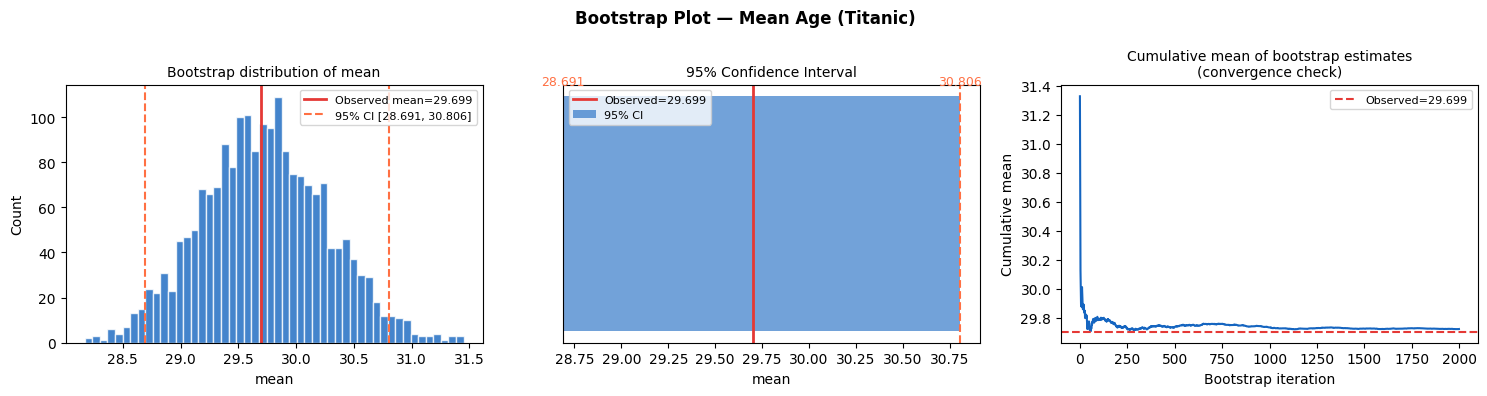

Bootstrap mean: 29.6991  95% CI: [28.6908, 30.8057]  SE: 0.5423


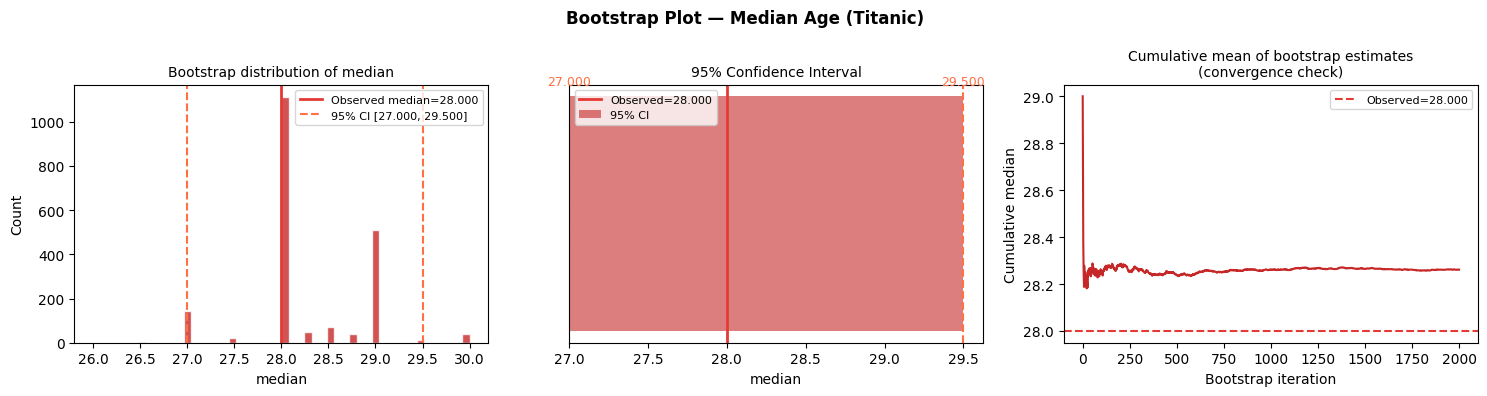

Bootstrap median: 28.0000  95% CI: [27.0000, 29.5000]  SE: 0.6150


In [3]:
def bootstrap_plot(data, statistic=np.mean, B=2000, stat_name='mean',
                   title=None, color='#1565C0'):
    """Bootstrap plot: sampling distribution + CI + stability for a statistic."""
    boot_stats = np.array([statistic(np.random.choice(data, size=len(data), replace=True))
                            for _ in range(B)])
    ci_lo, ci_hi = np.percentile(boot_stats, [2.5, 97.5])
    observed = statistic(data)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title or f'Bootstrap Plot — {stat_name}', fontsize=12, fontweight='bold')

    # Panel 1: Sampling distribution
    ax = axes[0]
    ax.hist(boot_stats, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(observed, color='#E53935', linewidth=2, label=f'Observed {stat_name}={observed:.3f}')
    ax.axvline(ci_lo, color='#FF7043', linewidth=1.5, linestyle='--', label=f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
    ax.axvline(ci_hi, color='#FF7043', linewidth=1.5, linestyle='--')
    ax.set_title(f'Bootstrap distribution of {stat_name}', fontsize=10)
    ax.set_xlabel(stat_name)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    # Panel 2: CI visualisation
    ax = axes[1]
    ax.barh([0], [ci_hi - ci_lo], left=ci_lo, height=0.4, color=color, alpha=0.6, label='95% CI')
    ax.axvline(observed, color='#E53935', linewidth=2, label=f'Observed={observed:.3f}')
    ax.axvline(ci_lo, color='#FF7043', linewidth=1.5, linestyle='--')
    ax.axvline(ci_hi, color='#FF7043', linewidth=1.5, linestyle='--')
    ax.set_yticks([])
    ax.set_title('95% Confidence Interval', fontsize=10)
    ax.set_xlabel(stat_name)
    ax.legend(fontsize=8)
    ax.text(ci_lo, 0.22, f'{ci_lo:.3f}', ha='center', fontsize=9, color='#FF7043')
    ax.text(ci_hi, 0.22, f'{ci_hi:.3f}', ha='center', fontsize=9, color='#FF7043')

    # Panel 3: Stability (bootstrap estimates in draw order)
    ax = axes[2]
    cumulative = np.cumsum(boot_stats) / np.arange(1, B+1)
    ax.plot(cumulative, color=color, linewidth=1.5)
    ax.axhline(observed, color='#E53935', linewidth=1.5, linestyle='--', label=f'Observed={observed:.3f}')
    ax.set_title('Cumulative mean of bootstrap estimates\n(convergence check)', fontsize=10)
    ax.set_xlabel('Bootstrap iteration')
    ax.set_ylabel(f'Cumulative {stat_name}')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    print(f"Bootstrap {stat_name}: {observed:.4f}  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]  SE: {boot_stats.std():.4f}")

import seaborn as sns
np.random.seed(42)
df = sns.load_dataset('titanic').dropna(subset=['age'])
age = df['age'].values

bootstrap_plot(age, statistic=np.mean, stat_name='mean', B=2000,
               title='Bootstrap Plot — Mean Age (Titanic)')

bootstrap_plot(age, statistic=np.median, stat_name='median', B=2000,
               title='Bootstrap Plot — Median Age (Titanic)', color='#C62828')

## Key Takeaways

| | |
|---|---|
| **Purpose** | Non-parametric uncertainty quantification for any statistic |
| **B** | Number of bootstrap samples — use B=1000–10000; more = smoother CI |
| **With replacement** | Each resample can repeat observations — this is essential |
| **Percentile CI** | 95% CI = [2.5th, 97.5th] percentile of bootstrap distribution |
| **Normal bootstrap dist** | Statistic is stable; parametric CI is fine |
| **Skewed bootstrap dist** | Use percentile or BCa CI instead of ±1.96·SE |
| **Stability panel** | Cumulative mean should plateau — if not, increase B |
| **Works for any stat** | Mean, median, SD, correlation, AUC, regression coefficient |
| **vs t-interval** | t-interval assumes normal data; bootstrap makes no distributional assumption |
| **vs jackknife** | Bootstrap: with replacement, B=1000+; Jackknife: leave-one-out, n samples |